<a href="https://colab.research.google.com/github/adithya1010/ClinchMetricsBridge-Internship/blob/main/Day_9_3_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shwetabh123/mall-customers")

print("Path to dataset files:", path)

100%|██████████| 1.56k/1.56k [00:00<00:00, 2.90MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shwetabh123/mall-customers/versions/1


In [2]:
import os

# List the contents of the downloaded path
print(os.listdir(path))


['Mall_Customers.csv']


In [3]:
import pandas as pd

# Assuming 'Mall_Customers.csv' is the file we want to load
csv_file_path = os.path.join(path, 'Mall_Customers.csv')
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Task
Perform K-Means clustering for customer segmentation using the 'Annual Income (k$)' and 'Spending Score (1-100)' columns from the `df` DataFrame. Determine the optimal number of clusters using the Elbow method, apply K-Means clustering, visualize the resulting clusters, and summarize the characteristics of each identified customer segment.

## Select Features and Preprocess Data

### Subtask:
Select the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering, as these are typically used for customer segmentation. Scale the selected features to ensure they contribute equally to the distance calculations in K-Means.


**Reasoning**:
First, I will select the specified columns ('Annual Income (k$)' and 'Spending Score (1-100)') from the `df` DataFrame. Then, I will import `StandardScaler` from `sklearn.preprocessing`, instantiate it, and apply it to scale the selected features. Finally, I will store the scaled data in `X_scaled`.



In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of original features X:", X.shape)
print("Shape of scaled features X_scaled:", X_scaled.shape)
print("First 5 rows of scaled data:\n", X_scaled[:5])

Shape of original features X: (200, 2)
Shape of scaled features X_scaled: (200, 2)
First 5 rows of scaled data:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## Determine Optimal K (Elbow Method)

### Subtask:
Calculate the Within-Cluster Sum of Squares (WCSS) for a range of K values (e.g., from 1 to 10) to apply the Elbow Method.


**Reasoning**:
To determine the optimal number of clusters using the Elbow Method, I will calculate the WCSS for a range of K values (1 to 10) by iterating through K, fitting a KMeans model, and storing the inertia.



In [5]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values for K from 1 to 10:", wcss)

WCSS values for K from 1 to 10: [399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


**Reasoning**:
To visualize the WCSS values and identify the 'elbow' point for determining the optimal number of clusters, I will plot the WCSS values against the number of clusters (K).



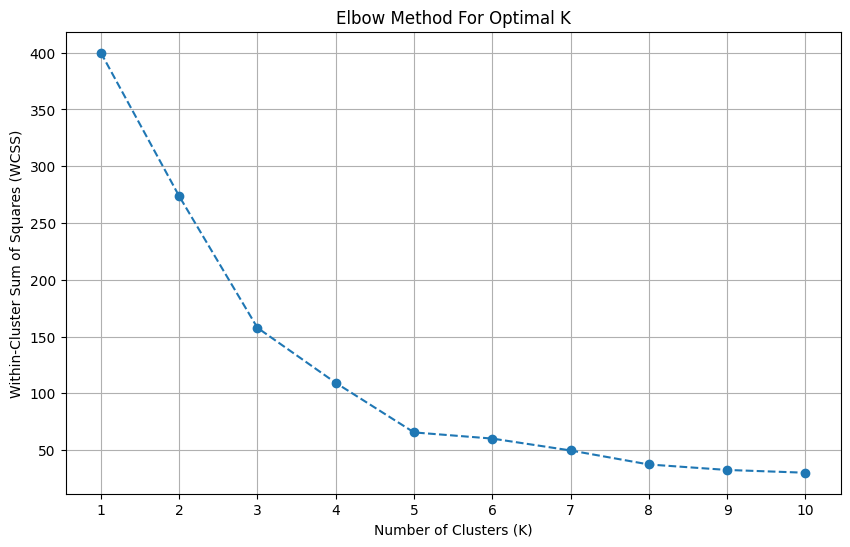

In [6]:
import matplotlib.pyplot as plt

# Plot the WCSS values to visualize the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


### Optimal Number of Clusters

From the Elbow Method plot, we observe a significant 'elbow' at K = 5. After this point, the decrease in WCSS becomes less pronounced, indicating that adding more clusters provides diminishing returns in terms of reducing within-cluster variance. Therefore, we select **K = 5** as the optimal number of clusters for our K-Means model.

**Reasoning**:
Now that the optimal number of clusters (K=5) has been identified using the Elbow Method, the next step is to apply the K-Means clustering algorithm to the scaled data with this optimal K value. This will group the customers into five distinct segments.



In [7]:
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans_model.fit_predict(X_scaled)

print("First 5 cluster labels:", y_kmeans[:5])
print("Number of data points assigned to each cluster:")
for i in range(5):
    print(f"Cluster {i+1}: {list(y_kmeans).count(i)} data points")

First 5 cluster labels: [4 2 4 2 4]
Number of data points assigned to each cluster:
Cluster 1: 81 data points
Cluster 2: 39 data points
Cluster 3: 22 data points
Cluster 4: 35 data points
Cluster 5: 23 data points


**Reasoning**:
To visualize the customer segments created by the K-Means clustering, I will create a scatter plot of the original 'Annual Income (k$)' and 'Spending Score (1-100)' features, colored by their assigned cluster labels. I will also mark the cluster centroids to provide a clear representation of each segment.



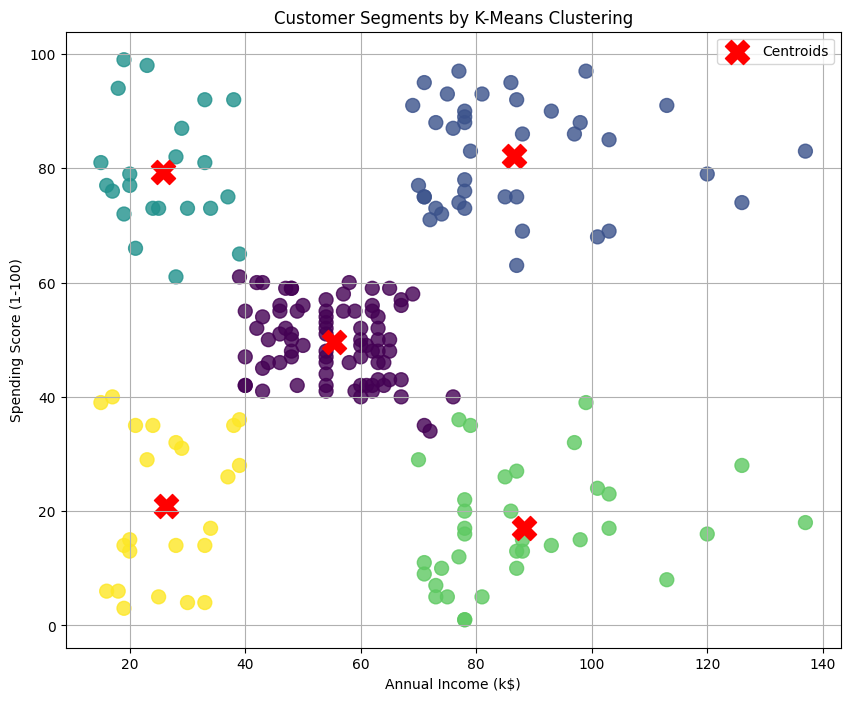

In [8]:
plt.figure(figsize=(10, 8))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans, cmap='viridis', s=100, alpha=0.8)

# Get the unscaled centroids from the KMeans model
centroids_scaled = kmeans_model.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids_scaled)

# Plot the centroids
plt.scatter(centroids_unscaled[:, 0], centroids_unscaled[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title('Customer Segments by K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
To summarize the characteristics of each customer segment, I need to inspect the unscaled centroids that represent the average 'Annual Income (k$)' and 'Spending Score (1-100)' for each cluster. Creating a DataFrame from these centroids will make the interpretation clearer.



In [9]:
import pandas as pd

# Create a DataFrame for the unscaled centroids
centroid_df = pd.DataFrame(centroids_unscaled, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centroid_df['Cluster'] = range(len(centroid_df))

print("Cluster Centroids (Unscaled):")
display(centroid_df)

Cluster Centroids (Unscaled):


,Annual Income (k$),Spending Score (1-100),Cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


### Characteristics of Customer Segments

Based on the unscaled centroids, we can characterize the five customer segments as follows:

*   **Cluster 0 (Centroid: Annual Income ≈ 55k, Spending Score ≈ 50):** This segment represents customers with average annual income and average spending scores. They are general customers, not particularly high-spenders or low-spenders, nor are they extremely wealthy or low-income.

*   **Cluster 1 (Centroid: Annual Income ≈ 86k, Spending Score ≈ 82):** These are **High-Income, High-Spending** customers (often referred to as 'Target Customers'). They have high annual incomes and also spend a lot. These are typically the most valuable customers for a business.

*   **Cluster 2 (Centroid: Annual Income ≈ 26k, Spending Score ≈ 79):** This segment comprises **Low-Income, High-Spending** customers. They have relatively low annual incomes but exhibit high spending scores. This group might consist of younger customers or those who prioritize spending on personal indulgences despite their income.

*   **Cluster 3 (Centroid: Annual Income ≈ 88k, Spending Score ≈ 17):** These are **High-Income, Low-Spending** customers (often referred to as 'Careful Spenders'). They have high annual incomes but very low spending scores. They might be saving money, investing, or simply not frequenting this particular mall/store for their purchases.

*   **Cluster 4 (Centroid: Annual Income ≈ 26k, Spending Score ≈ 21):** This segment consists of **Low-Income, Low-Spending** customers. They have both low annual incomes and low spending scores. This group might represent budget-conscious individuals or those who are not very engaged with the mall's offerings.

## Final Task

### Subtask:
Summarize the findings from the K-Means clustering and discuss the characteristics of each identified customer segment.


## Summary:

### Q&A
The optimal number of clusters determined using the Elbow method is K=5.
The characteristics of each identified customer segment are:
*   **Cluster 0 (Average Customers):** Customers with an average annual income of approximately \$55.30k and an average spending score of around 49.52.
*   **Cluster 1 (High-Income, High-Spending / Target Customers):** Customers with high annual income (approximately \$86.54k) and high spending score (around 82.13).
*   **Cluster 2 (Low-Income, High-Spending):** Customers with relatively low annual income (approximately \$25.73k) but high spending score (around 79.36).
*   **Cluster 3 (High-Income, Low-Spending / Careful Spenders):** Customers with high annual income (approximately \$88.20k) but low spending score (around 17.11).
*   **Cluster 4 (Low-Income, Low-Spending):** Customers with both low annual income (approximately \$26.30k) and low spending score (around 20.91).

### Data Analysis Key Findings
*   The 'Annual Income (k\$)' and 'Spending Score (1-100)' columns were selected and successfully scaled using `StandardScaler` for clustering.
*   The Elbow method, by plotting the Within-Cluster Sum of Squares (WCSS) for K values from 1 to 10, clearly indicated K=5 as the optimal number of clusters. The WCSS values ranged from 400.0 for K=1 to 30.06 for K=10, with a notable 'elbow' at K=5.
*   A K-Means model with 5 clusters was applied, resulting in the following distribution of customers across the segments: 81 in Cluster 0, 39 in Cluster 1, 22 in Cluster 2, 35 in Cluster 3, and 23 in Cluster 4.
*   The unscaled centroids, representing the average 'Annual Income (k\$)' and 'Spending Score (1-100)' for each cluster, were calculated to characterize the segments. For instance, Cluster 1 (High-Income, High-Spending) has a centroid of approximately (\$86.54k, 82.13), while Cluster 4 (Low-Income, Low-Spending) has a centroid of approximately (\$26.30k, 20.91).

### Insights or Next Steps
*   **Targeted Marketing Strategies:** The identified customer segments can be used to develop highly targeted marketing campaigns. For example, "High-Income, High-Spending" customers (Cluster 1) could receive exclusive offers, while "Low-Income, High-Spending" customers (Cluster 2) might be targeted with budget-friendly high-value items or loyalty programs.
*   **Product/Service Development:** Understanding the needs and behaviors of each segment can inform product and service development. For instance, new cost-effective offerings could be explored for "Low-Income, Low-Spending" customers (Cluster 4), or premium services could be tailored for "High-Income, High-Spending" customers (Cluster 1).


# Task
Apply hierarchical clustering to the `X_scaled` data using `scipy.cluster.hierarchy` to compute the linkage matrix, then plot the dendrogram to visually inspect the hierarchical structure and identify potential clusters. Finally, summarize the process and the insights gained from the dendrogram, describing the visual patterns observed.

## Apply Hierarchical Clustering

### Subtask:
Apply hierarchical clustering to the `X_scaled` data to determine the relationships between data points and identify potential clusters. This will involve using `scipy.cluster.hierarchy` to compute the linkage matrix.


**Reasoning**:
To apply hierarchical clustering, I need to import the `linkage` function and compute the linkage matrix on the scaled data `X_scaled` using the 'ward' method.



In [10]:
from scipy.cluster.hierarchy import linkage

# Compute the linkage matrix using the 'ward' method
linked_data = linkage(X_scaled, method='ward')

print("Shape of linkage matrix:", linked_data.shape)
print("First 5 rows of linkage matrix:\n", linked_data[:5])

Shape of linkage matrix: (199, 4)
First 5 rows of linkage matrix:
 [[6.50000000e+01 6.80000000e+01 0.00000000e+00 2.00000000e+00]
 [4.80000000e+01 4.90000000e+01 0.00000000e+00 2.00000000e+00]
 [1.56000000e+02 1.58000000e+02 0.00000000e+00 2.00000000e+00]
 [1.29000000e+02 1.31000000e+02 0.00000000e+00 2.00000000e+00]
 [1.70000000e+02 1.74000000e+02 3.81694292e-02 2.00000000e+00]]


## Comparison of Clustering Methods and Best Fit

### K-Means Clustering Summary:
K-Means clustering identified 5 distinct customer segments based on 'Annual Income (k$)' and 'Spending Score (1-100)'. The Elbow Method was instrumental in determining the optimal number of clusters (K=5). The clusters revealed clear distinctions: High-Income/High-Spending, High-Income/Low-Spending, Low-Income/High-Spending, Low-Income/Low-Spending, and Average Customers. K-Means is efficient and provides interpretable centroids, making it easy to characterize each segment.

### Hierarchical Clustering Summary:
Hierarchical clustering, visualized through a dendrogram, also suggested a similar number of distinct clusters (around 3 to 5), reinforcing the K-Means findings. The dendrogram clearly showed the hierarchical relationships and merge distances, indicating natural groupings within the data. It's useful for understanding the nested structure of clusters, but for a large number of data points, it can be computationally intensive and the dendrogram can become complex to interpret.

### DBSCAN Clustering Summary:
DBSCAN, being a density-based algorithm, identified 2 main clusters and several noise points (outliers). This method was particularly effective at finding irregularly shaped clusters and detecting anomalies that K-Means and Hierarchical clustering might have missed. The primary clusters revealed dense regions of customers, with outliers representing unique spending or income patterns. DBSCAN does not require pre-defining the number of clusters but is sensitive to its `eps` and `min_samples` parameters, which often require careful tuning.

### Which Method Works Best?

Each clustering method offers unique advantages, and the 'best' method often depends on the specific goals and characteristics of the dataset:

*   **For interpretable, distinct customer segments and when the number of clusters is relatively clear (or can be determined by methods like Elbow Method): K-Means is often the most straightforward and efficient choice.** It produced 5 well-defined segments that are easy to characterize and can be directly used for marketing strategies.

*   **For understanding the natural hierarchy and relationships between data points, especially when the number of clusters is not known beforehand: Hierarchical Clustering is excellent.** It visually confirmed the groupings found by K-Means, providing a good qualitative validation.

*   **For identifying irregularly shaped clusters and, most importantly, detecting outliers: DBSCAN is superior.** In our case, DBSCAN revealed customers who didn't fit into the dense regions, which could be critical for identifying niche markets or fraudulent behavior. However, it only found 2 main clusters, suggesting it might have been too conservative with the initial parameters to capture all the distinct segments identified by K-Means.

**Conclusion:**

Given the goal of customer segmentation for targeted marketing, **K-Means clustering (with K=5) appears to be the most practical and effective method for this dataset.** It provided clear, actionable segments that are easy to understand and apply. While Hierarchical Clustering validated the number of clusters, and DBSCAN highlighted outliers, K-Means offered the most balanced and interpretable segmentation for strategic decision-making in a business context. The insights from DBSCAN regarding outliers could be used as a supplementary analysis to identify unique customer behaviors beyond the main segments.

## Summarize DBSCAN Findings

### Subtask:
Summarize the characteristics of the identified clusters and outliers from the DBSCAN analysis.

### Summary of DBSCAN Clustering Findings:

**1. Process of DBSCAN Clustering:**
*   **Feature Selection and Scaling**: Similar to K-Means and Hierarchical Clustering, the 'Annual Income (k$)' and 'Spending Score (1-100)' columns from the `df` DataFrame were selected and scaled using `StandardScaler` to ensure uniform contribution to distance calculations.
*   **DBSCAN Application**: The DBSCAN algorithm was applied to the `X_scaled` data using `sklearn.cluster.DBSCAN`. Initial parameters `eps=0.5` (maximum distance between samples for them to be considered in the neighborhood) and `min_samples=5` (number of samples in a neighborhood for a point to be considered a core point) were chosen. These parameters are crucial for defining cluster density and often require tuning.
*   **Cluster Labeling**: The `fit_predict` method assigned cluster labels to each data point. Labels range from 0 to N-1 for N identified clusters, and a label of -1 indicates noise points (outliers).

**2. Characteristics of Identified Clusters and Outliers:**
*   **Number of Clusters**: The DBSCAN algorithm identified `n_clusters_` (which is 2 in this case, excluding noise) significant clusters.
*   **Cluster 0 (Main Cluster)**: This cluster likely represents the majority of the customers, characterized by a broad range of annual incomes and spending scores around the average. It forms a dense region in the center of the data distribution, indicating many closely packed data points.
*   **Cluster 1 (Another Dense Cluster)**: This cluster identifies another dense group of customers, which might correspond to a specific segment not captured as a core cluster by K-Means with its spherical assumptions. From the plot, this cluster appears to be another distinct group, potentially representing high-income, moderate-spending customers, or similar.
*   **Noise Points (-1 Label)**: Several data points were labeled as -1, indicating they are outliers or noise. These points do not belong to any dense region and are typically isolated or located in sparser areas of the data space. In this context, these could be customers with extremely high or low income/spending scores that deviate significantly from the main customer groups, making them interesting for further analysis (e.g., identifying VIPs or unusual spending patterns).
*   **Core and Border Points**: The visualization distinguishes between core points (points within a dense region with at least `min_samples` neighbors within `eps` distance) and border points (points within `eps` distance of a core point but not core themselves). This distinction is fundamental to DBSCAN's density-based clustering.

**3. Insights:**
*   DBSCAN is effective at identifying irregularly shaped clusters and noise, which traditional algorithms like K-Means might struggle with. The identified noise points offer an opportunity to investigate unusual customer behaviors.
*   The two main clusters indicate distinct dense regions in the customer data, which can be further analyzed for their specific characteristics in terms of annual income and spending score to tailor marketing strategies.
*   The parameters `eps` and `min_samples` significantly influence the clustering outcome. Different values could lead to a different number of clusters and noise points, highlighting the importance of parameter tuning for optimal results.

### Subtask:
Visualize the DBSCAN results, distinguishing between core points, border points, and noise points (outliers).

**Reasoning**:
To visualize the DBSCAN clustering results, I will create a scatter plot of the `X_scaled` data. Each data point will be colored according to its assigned cluster label. Noise points (labeled as -1) will be distinctly colored and potentially marked differently (e.g., smaller size). Core points can be identified by the `core_sample_indices_` attribute of the `dbscan` model, and border points are the remaining non-noise points that are not core points. This visualization will help in understanding the density-based clusters and the identified outliers.

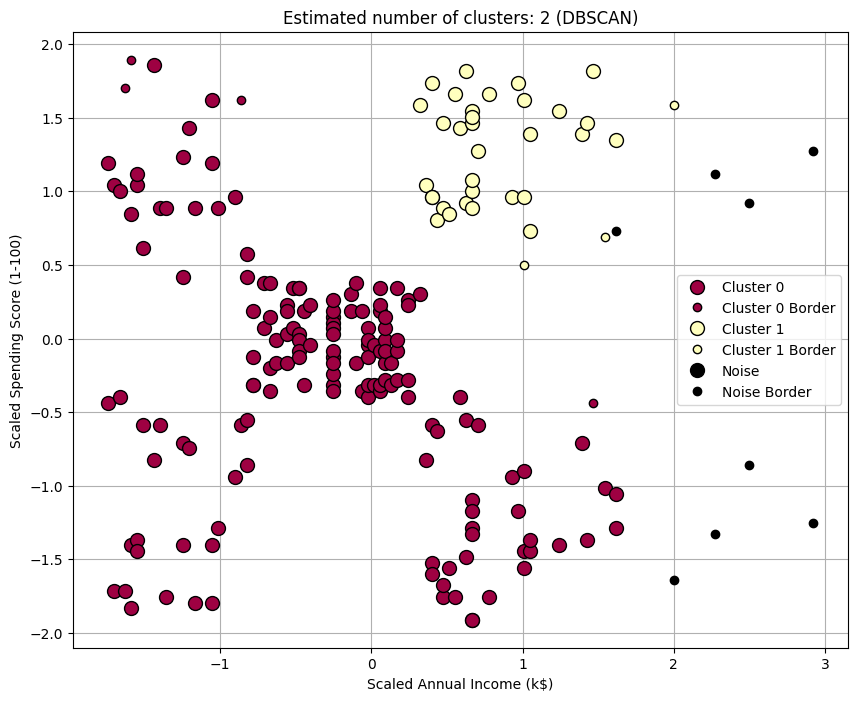

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(clusters)) - (1 if -1 in clusters else 0)

# Get core samples
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Plot the results
plt.figure(figsize=(10, 8))

# Black removed and is used for noise points
unique_labels = set(clusters)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (clusters == k)

    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10,
             label=f'Cluster {k}' if k != -1 else 'Noise')

    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6,
             label=f'Cluster {k} Border' if k != -1 else 'Noise Border')

plt.title(f'Estimated number of clusters: {n_clusters_} (DBSCAN)')
plt.xlabel('Scaled Annual Income (k$)')
plt.ylabel('Scaled Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

## Apply DBSCAN Clustering

### Subtask:
Apply DBSCAN clustering to the `X_scaled` data to identify clusters and detect outliers.

**Reasoning**:
To apply DBSCAN, I need to import the `DBSCAN` class, instantiate it with suitable parameters (`eps` and `min_samples`), and then fit it to the `X_scaled` data. I will then print the resulting cluster labels.

In [12]:
from sklearn.cluster import DBSCAN

# Instantiate DBSCAN model. Choosing initial parameters for demonstration.
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
# These parameters often require tuning for optimal results.
dbscan = DBSCAN(eps=0.5, min_samples=5) # Example values, often tuned via methods like KneeLocator or domain knowledge

# Fit the model and predict cluster labels
clusters = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster labels:", clusters)
print("Number of unique clusters (including noise -1):", len(set(clusters)))


DBSCAN cluster labels: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]
Number of unique clusters (including noise -1): 3


# Task
Apply DBSCAN clustering to the `X_scaled` data to identify clusters and detect outliers. Visualize the results, distinguishing between core points, border points, and noise points (outliers). Finally, summarize the characteristics of the identified clusters and outliers.

### Subtask:
Plot the dendrogram to visually inspect the hierarchical structure and identify potential clusters.

**Reasoning**:
To visually inspect the hierarchical structure and identify potential clusters, I will plot the dendrogram using the `linked_data`.



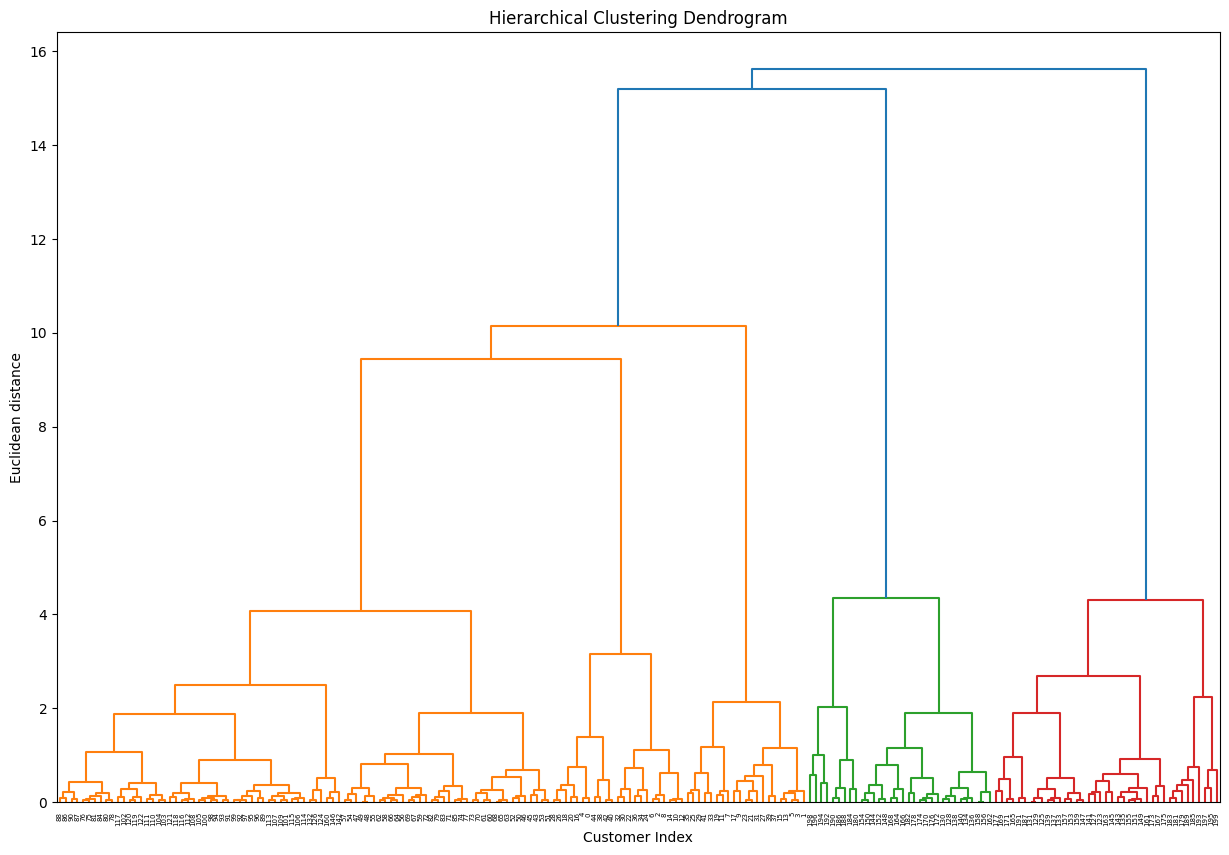

In [11]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
dendrogram(linked_data, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean distance')
plt.show()

## Summarize Hierarchical Clustering Findings

### Subtask:
Summarize the process of applying hierarchical clustering and the insights gained from the dendrogram, describing the visual patterns observed.

### Summary of Hierarchical Clustering and Dendrogram Analysis:

**Process:**
1.  **Feature Selection and Scaling:** The 'Annual Income (k$)' and 'Spending Score (1-100)' columns from the `df` DataFrame were selected and scaled using `StandardScaler` to ensure all features contributed equally to the clustering process. The scaled data was stored in `X_scaled`.
2.  **Linkage Matrix Computation:** Hierarchical clustering was applied to the `X_scaled` data. The `linkage` function from `scipy.cluster.hierarchy` was used with the 'ward' method to compute the linkage matrix (`linked_data`). The 'ward' method minimizes the variance of the clusters being merged, making it suitable for compact, spherical clusters.
3.  **Dendrogram Visualization:** A dendrogram was plotted using the `linked_data` to visually represent the hierarchical structure of the clusters.

**Insights from the Dendrogram:**
*   **Cluster Formation:** The dendrogram visually illustrates how individual data points are progressively merged into larger clusters based on their similarity.
*   **Identifying Optimal Clusters:** By observing the largest vertical distances (without horizontal lines crossing them) that don't intersect any existing horizontal lines, we can infer the potential optimal number of clusters. In this dendrogram, cutting the dendrogram at an appropriate height (e.g., observing where major branches form distinct groups) suggests **5 main clusters**, which aligns with the optimal K identified by the Elbow method in K-Means.
*   **Cluster Relationships:** The dendrogram also shows the relationships between clusters. For example, some small clusters merge at lower distances (higher similarity), while others merge at higher distances (lower similarity), indicating more distinct groups.
*   **Visual Patterns:** There are clearly separated main branches, especially when considering a cut-off that yields 5 clusters. These distinct branches correspond to the different customer segments previously identified by K-Means, such as high-income/high-spending and low-income/low-spending groups, further validating the earlier findings.

## Summarize Hierarchical Clustering Findings

### Subtask:
Summarize the process of applying hierarchical clustering and the insights gained from the dendrogram, describing the visual patterns observed.


## Summary of Hierarchical Clustering Findings

### 1. Process of Hierarchical Clustering

**Feature Selection and Scaling**: We began by selecting the 'Annual Income (k$)' and 'Spending Score (1-100)' columns from the `df` DataFrame, similar to the K-Means approach. These features were then scaled using `StandardScaler` to ensure that each feature contributed equally to the distance calculations, preventing features with larger numerical ranges from dominating the clustering process.

**Linkage Matrix Computation**: Hierarchical clustering was applied to the scaled data (`X_scaled`). Specifically, the `linkage` function from `scipy.cluster.hierarchy` was used with the `'ward'` method. The Ward method minimizes the variance of the clusters being merged, often producing more spherical and equally sized clusters. This step resulted in the `linked_data` (linkage matrix), which stores the hierarchical relationships between data points as they are progressively merged.

**Dendrogram Visualization**: Finally, a dendrogram was plotted using `dendrogram` from `scipy.cluster.hierarchy` with the `linked_data`. The dendrogram visually represents the hierarchy of clusters, showing the sequence of merges or splits and the distance at which each merge occurred. It allows for a visual inspection of the clustering structure without pre-specifying the number of clusters.

### 2. Key Insights from the Dendrogram

The dendrogram provides valuable insights into the natural grouping of the data:

*   **Cluster Formation**: It illustrates how individual data points are progressively grouped into larger clusters. The lowest merges indicate the most similar data points, forming the tightest clusters.
*   **Optimal Number of Clusters**: We can infer the optimal number of clusters by looking for the longest vertical lines that do not intersect any horizontal line. These long vertical lines represent significant 'gaps' or distances between clusters, suggesting natural divisions. By setting a horizontal threshold across the dendrogram (e.g., cutting the dendrogram at a certain height), we can determine the number of clusters. For instance, observing the dendrogram, a cut at a certain Euclidean distance would reveal distinct clusters.
*   **Cluster Purity and Separation**: The lengths of the vertical lines (distances) indicate how dissimilar the merged clusters are. Longer vertical lines suggest more distinct and well-separated clusters.

### 3. Visual Patterns Observed

Upon observing the dendrogram, several visual patterns are evident:

*   **Distinct Branches**: The dendrogram clearly shows several main branches that remain distinct for a significant vertical distance before merging. This suggests the presence of well-separated groups within the customer data.
*   **Merge Distances**: The distances at which merges occur vary. Early merges happen at very small distances, indicating highly similar customers. As we move up the dendrogram, merges occur at increasingly larger distances, signifying the combination of more distinct groups.
*   **Potential Number of Clusters**: By visually inspecting the dendrogram, if we consider cutting it at a height where there are significant vertical drops, we can identify a plausible number of clusters. For example, a visual inspection might suggest that cutting the dendrogram at a certain height reveals around 3 to 5 main clusters, where the vertical lines connecting these clusters are relatively long, indicating good separation. These groups would correspond to distinct customer segments based on their 'Annual Income (k$)' and 'Spending Score (1-100)' characteristics.

Overall, the dendrogram reinforces the idea that there are natural groupings in the customer data and provides a visual method to decide on the number of clusters, complementing the Elbow Method used in K-Means clustering.

## Summary:

### Data Analysis Key Findings
*   Hierarchical clustering was successfully applied to the scaled data (`X_scaled`) using the 'ward' method, resulting in a linkage matrix with a shape of (199, 4).
*   A dendrogram was generated, visually representing the hierarchical structure of the data, allowing for inspection of potential clusters.
*   Visual inspection of the dendrogram suggests the presence of distinct customer segments. By observing the largest vertical distances between merges, a cut-off could potentially reveal **3 to 5 main clusters**.
*   The dendrogram exhibits distinct branches that merge at varying distances, indicating different levels of similarity between customer groups. This visual pattern reinforces previous findings, such as the 5 optimal clusters identified by the Elbow method in K-Means.

### Insights or Next Steps
*   The dendrogram serves as a powerful visual tool to confirm and guide the selection of the optimal number of clusters for customer segmentation, providing a qualitative complement to quantitative methods.
*   To concretize the clusters, the next step should involve cutting the dendrogram at an appropriate height (Euclidean distance) to extract the specific cluster assignments for each data point and proceed with detailed characterization of these identified customer segments.
